<a href="https://colab.research.google.com/github/IsaacGSolis/Mineria-de-Datos-IEGS/blob/main/ArbolDecisionE2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [25]:
data={
    "IMC": ["Alto", "Alto", "Alto", "Normal", "Normal",
            "Normal", "Alto", "Normal", "Normal", "Alto"],

    "Azucar_Sangre": ["Alta", "Alta", "Normal", "Alta", "Normal",
                      "Normal", "Normal", "Alta", "Normal", "Alta"],

    "Actividad_Fisica": ["Poca", "Mucha", "Poca", "Poca", "Mucha",
                         "Poca", "Mucha", "Mucha", "Poca", "Poca"],

    "Diabetes": ["Sí", "Sí", "Sí", "Sí", "No",
                 "No", "No", "No", "No", "Sí"]
}
df=pd.DataFrame(data)
df

,IMC,Azucar_Sangre,Actividad_Fisica,Diabetes
0,Alto,Alta,Poca,Sí
1,Alto,Alta,Mucha,Sí
2,Alto,Normal,Poca,Sí
3,Normal,Alta,Poca,Sí
4,Normal,Normal,Mucha,No
5,Normal,Normal,Poca,No
6,Alto,Normal,Mucha,No
7,Normal,Alta,Mucha,No
8,Normal,Normal,Poca,No
9,Alto,Alta,Poca,Sí


In [26]:
df_encoded = df.copy()
encoders = {}
for columna in df.columns:
    encoders[columna] = LabelEncoder()
    df_encoded[columna] = encoders[columna].fit_transform(df[columna])
df_encoded

,IMC,Azucar_Sangre,Actividad_Fisica,Diabetes
0,0,0,1,1
1,0,0,0,1
2,0,1,1,1
3,1,0,1,1
4,1,1,0,0
5,1,1,1,0
6,0,1,0,0
7,1,0,0,0
8,1,1,1,0
9,0,0,1,1


In [27]:
atributos = ["IMC", "Azucar_Sangre", "Actividad_Fisica"]
X = df_encoded[atributos]
y = df_encoded["Diabetes"]

ID3

In [28]:
modelo_id3 = DecisionTreeClassifier(
    criterion="entropy",
    random_state=42
)
modelo_id3.fit(X, y)
print(f"Profundidad del árbol: {modelo_id3.get_depth()}")
print(f"Número de hojas:       {modelo_id3.get_n_leaves()}")

Profundidad del árbol: 3
Número de hojas:       6


In [29]:
importancias = pd.Series(
    modelo_id3.feature_importances_,
    index=atributos
).sort_values(ascending=False)
for atributo, valor in importancias.items():
    print(f"  {atributo}: {valor:.4f}")
print()
print("Nodo raíz ID3:")
print(importancias.index[0])

  IMC: 0.3610
  Actividad_Fisica: 0.3610
  Azucar_Sangre: 0.2781

Nodo raíz ID3:
IMC


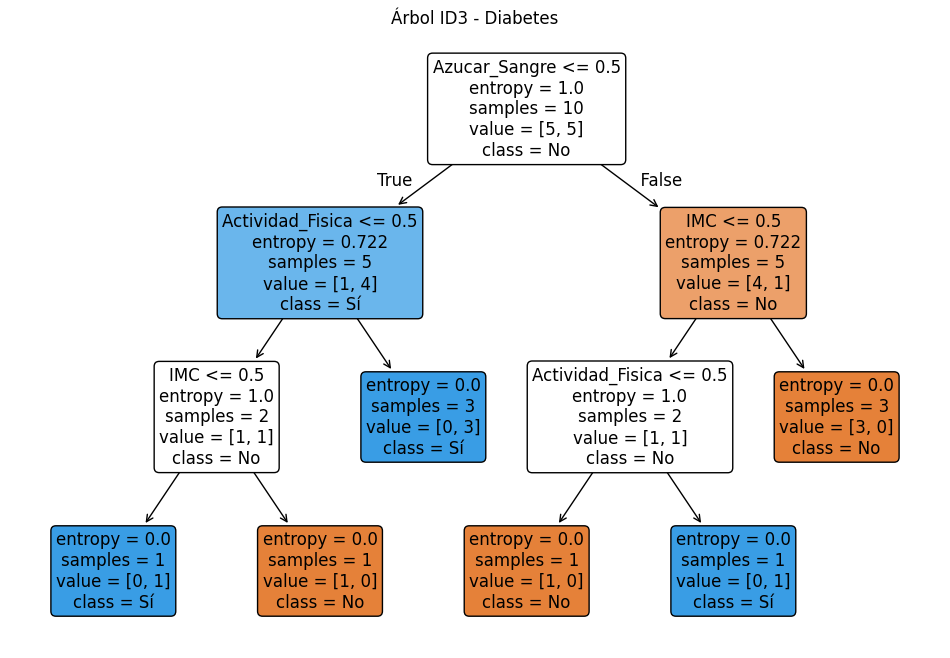

In [30]:
plt.figure(figsize=(12,8))
plot_tree(
    modelo_id3,
    feature_names=atributos,
    class_names=encoders["Diabetes"].classes_,
    filled=True,
    rounded=True
)
plt.title("Árbol ID3 - Diabetes")
plt.show()

CART

In [31]:
modelo_cart = DecisionTreeClassifier(
    criterion="gini",
    random_state=42
)
modelo_cart.fit(X, y)
print(f"Profundidad del árbol: {modelo_cart.get_depth()}")
print(f"Número de hojas:       {modelo_cart.get_n_leaves()}")

Profundidad del árbol: 3
Número de hojas:       6


In [32]:
importancias_cart = pd.Series(
    modelo_cart.feature_importances_,
    index=atributos
).sort_values(ascending=False)
print("Importancia de atributos (Gini):")
for atributo, valor in importancias_cart.items():
    print(f"{atributo}: {valor:.4f}")
print("\nNodo raíz CART:")
print(importancias_cart.index[0])

Importancia de atributos (Gini):
Azucar_Sangre: 0.3600
IMC: 0.3200
Actividad_Fisica: 0.3200

Nodo raíz CART:
Azucar_Sangre


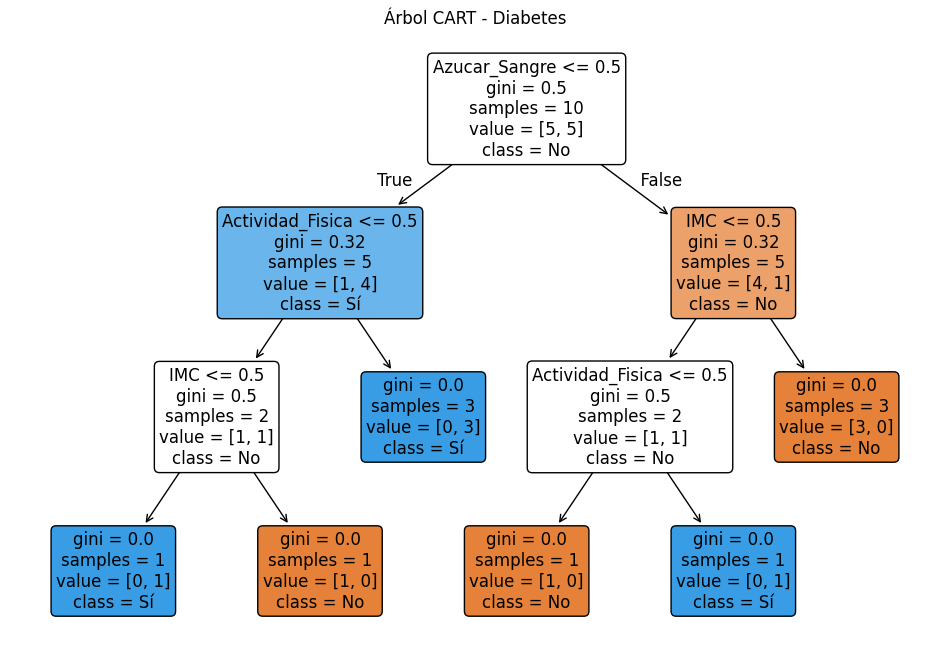

In [33]:
plt.figure(figsize=(12,8))
plot_tree(
    modelo_cart,
    feature_names=atributos,
    class_names=encoders["Diabetes"].classes_,
    filled=True,
    rounded=True
)
plt.title("Árbol CART - Diabetes")
plt.show()

In [34]:
nuevo = pd.DataFrame({
    "IMC": ["Alto"],
    "Azucar_Sangre": ["Alta"],
    "Actividad_Fisica": ["Poca"]
})
for col in nuevo.columns:
    nuevo[col] = encoders[col].transform(nuevo[col])
pred_id3 = modelo_id3.predict(nuevo)
pred_cart = modelo_cart.predict(nuevo)
print("\nPredicción ID3:")
print(encoders["Diabetes"].inverse_transform(pred_id3)[0])
print("\nPredicción CART:")
print(encoders["Diabetes"].inverse_transform(pred_cart)[0])


Predicción ID3:
Sí

Predicción CART:
Sí
